### 3: Credit Exposure, Risk Analysis, and Forecasting
---------------------------------------------------------

Analyze credit risk and develop a 3-month profit/loss forecast:

1. Calculate current credit exposure:
   - Total outstanding loans
   - Aging analysis of unpaid loans
   - Exposure by tenure segment
2. Develop a risk scoring methodology based on:
   - Historical repayment behavior
   - Loan amount relative to average
   - Tenure preference
3. Create a 3-month forecast using Python:
   - Use time-series forecasting (ARIMA or LSTM) for loan volume
   - Project expected revenue from fees
   - Estimate default rates and losses
   - Calculate net profit/loss projections
4. Perform sensitivity analysis on key variables:
   - Impact of increased default rates
   - Effect of changing fee structures
   - Influence of loan volume changes

Expected output: Credit exposure analysis, risk assessment methodology, 3-month P&L forecast with Python code, and sensitivity analysis.

=== CREDIT EXPOSURE AND RISK ANALYSIS ===
Loading and preparing data...
Successfully loaded data:
- Disbursements: 26585 rows, 6 columns
- Repayments: 66016 rows, 5 columns

Sample of raw Disbursements data:
                                         customer_id  disb_date   tenure                       account_num  loan_amount  loan_fee
0  91810ca1aa097db79f050f38e9946fa5482b4e28c925e2... 2024-03-19  14 days  3O66YENWELA6E2H1R9YLX0LDZNOMNHD4          360     43.20
1  42ca06e6fe1ff9803e82a5c20184671b54090e488f78d6... 2024-03-19   7 days  6XWHXKKR1W2HIA8I0V75PZFZBXUUGSVO           70      7.00
2  b23747f53af805e18ad16a4ef235b6642d88f9134644ff... 2024-03-19   7 days  OCGK3RJZ91A999VXD4VB3LATPSME3J5L         3500    350.00

Sample of raw Repayments data:
                         date_time                                        customer_id  amount  rep_month repayment_type
0  27-JUN-24 07.16.36.000000000 AM  683131338d401fda38410a808797b7706bc3e364d0fe77...  500.65     202406      Automatic


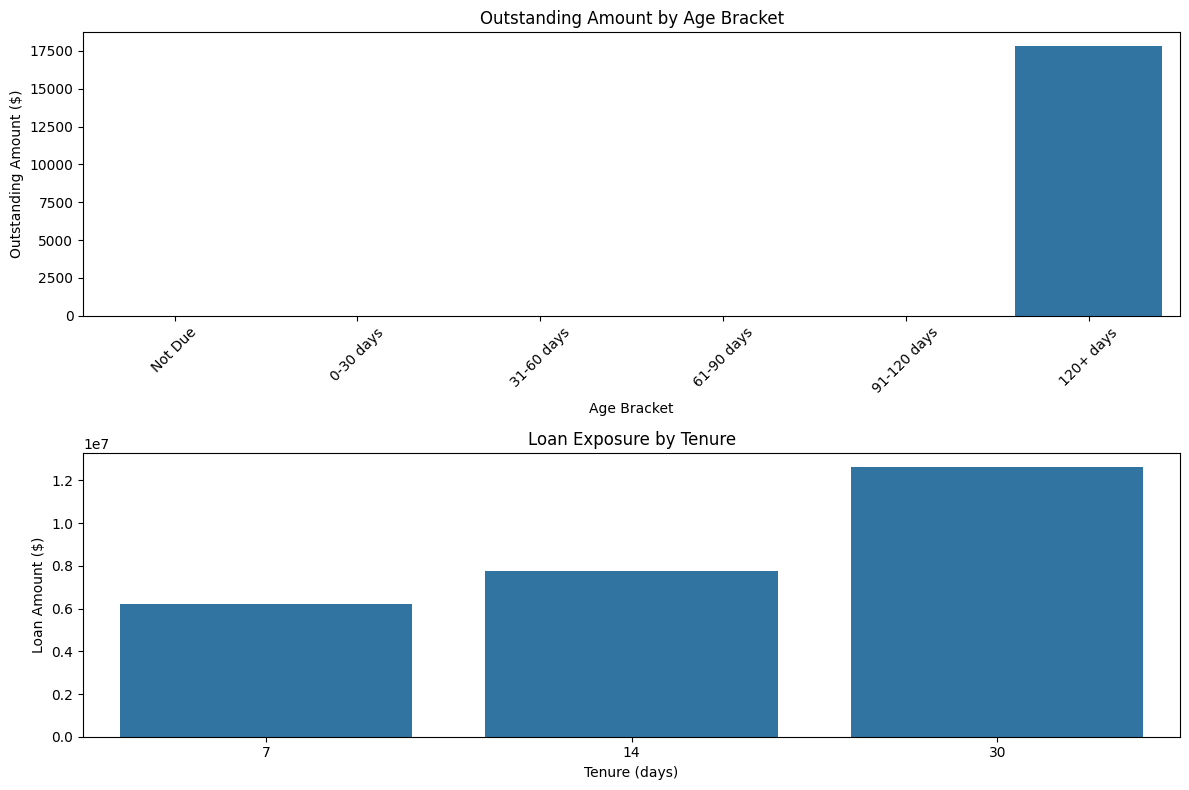

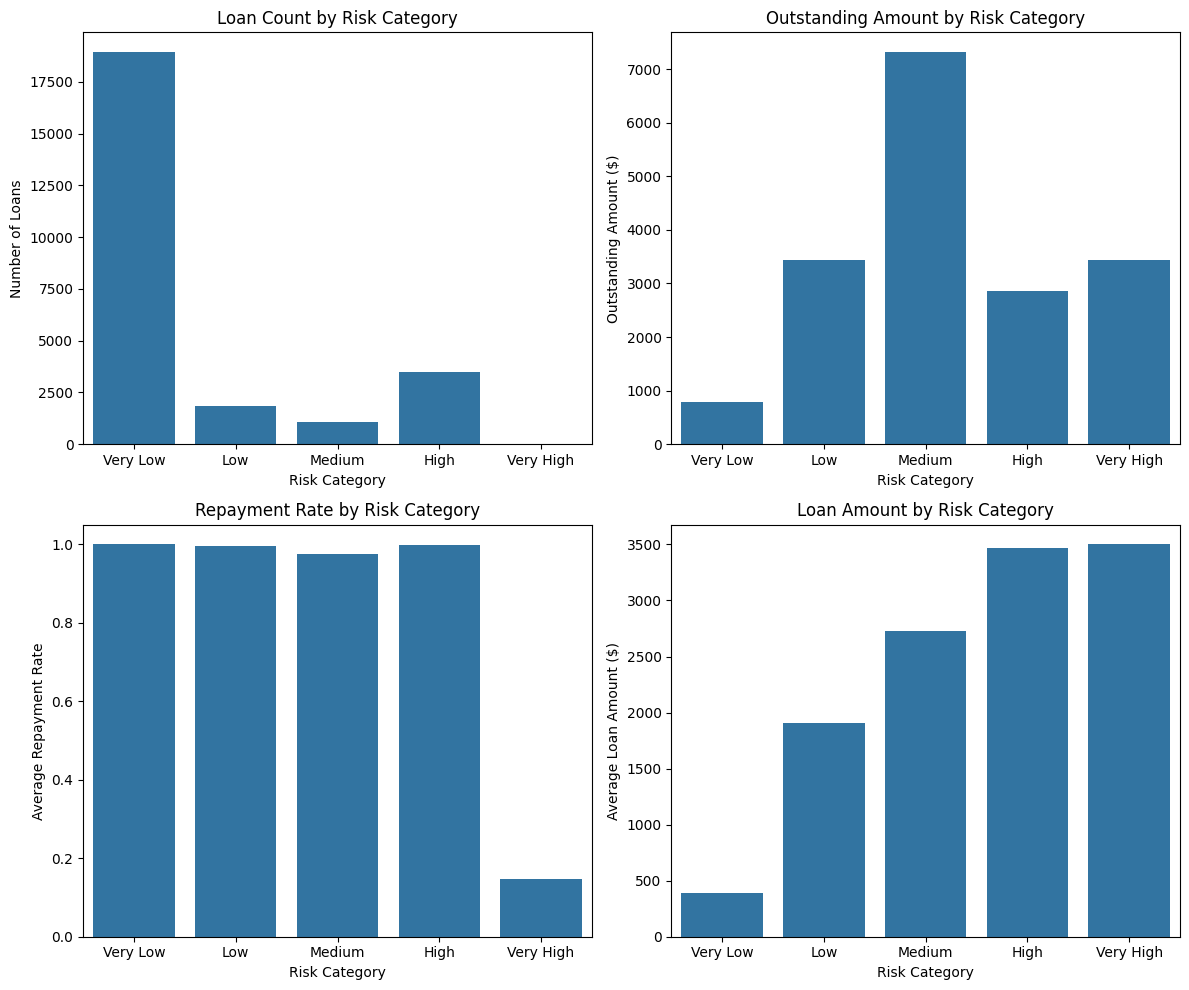

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Define file path
excel_file = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\BI Analyst Case study\assets\BI_Analyst_Case_Study_Data.xlsx"

print("=== CREDIT EXPOSURE AND RISK ANALYSIS ===")
print("Loading and preparing data...")

# Function to load and validate Excel data
def load_excel_data(file_path):
    try:
        # Load both sheets
        disbursements = pd.read_excel(file_path, sheet_name='Disbursements')
        repayments = pd.read_excel(file_path, sheet_name='Repayments')

        # Basic validation
        if disbursements.empty or repayments.empty:
            raise ValueError("One or both sheets are empty")

        print(f"Successfully loaded data:")
        print(f"- Disbursements: {disbursements.shape[0]} rows, {disbursements.shape[1]} columns")
        print(f"- Repayments: {repayments.shape[0]} rows, {repayments.shape[1]} columns")

        return disbursements, repayments

    except Exception as e:
        print(f"Error loading data: {e}")
        raise

# Load the data
disbursements_raw, repayments_raw = load_excel_data(excel_file)

# Display sample of raw data
print("\nSample of raw Disbursements data:")
print(disbursements_raw.head(3))
print("\nSample of raw Repayments data:")
print(repayments_raw.head(3))

# Check for missing values in raw data
print("\nMissing values in Disbursements:")
print(disbursements_raw.isnull().sum())
print("\nMissing values in Repayments:")
print(repayments_raw.isnull().sum())

# ===== CLEAN DISBURSEMENTS DATA =====
def clean_disbursements(df):
    print("\n=== Cleaning Disbursements Data ===")

    # Create a copy to avoid modifying the original
    cleaned_df = df.copy()

    # Rename columns for clarity
    cleaned_df.rename(columns={
        'customer_id': 'customer_id',
        'disb_date': 'disbursement_date',
        'tenure': 'tenure_str',
        'account_num': 'account_number',
        'loan_amount': 'loan_amount',
        'loan_fee': 'loan_fee'
    }, inplace=True)

    # Convert date to datetime
    cleaned_df['disbursement_date'] = pd.to_datetime(cleaned_df['disbursement_date'], errors='coerce')
    print(f"- Converted disbursement_date to datetime. Null dates: {cleaned_df['disbursement_date'].isnull().sum()}")

    # Extract numeric values from tenure
    def extract_tenure_days(tenure_val):
        if isinstance(tenure_val, str):
            # Extract digits only
            digits = ''.join(filter(str.isdigit, tenure_val))
            return int(digits) if digits else np.nan
        elif isinstance(tenure_val, (int, float)):
            return tenure_val
        return np.nan

    cleaned_df['tenure_days'] = cleaned_df['tenure_str'].apply(extract_tenure_days)
    print(f"- Extracted tenure_days. Null values: {cleaned_df['tenure_days'].isnull().sum()}")

    # Drop rows with missing essential data
    before_drop = len(cleaned_df)
    cleaned_df.dropna(subset=['customer_id', 'disbursement_date', 'loan_amount', 'tenure_days'], inplace=True)
    print(f"- Dropped {before_drop - len(cleaned_df)} rows with missing essential data")

    # Convert tenure_days to integer
    cleaned_df['tenure_days'] = cleaned_df['tenure_days'].astype(int)

    # Calculate expected repayment date
    cleaned_df['expected_repayment_date'] = cleaned_df['disbursement_date'] + pd.to_timedelta(cleaned_df['tenure_days'], unit='D')

    # Calculate expected repayment amount (loan amount + fee)
    cleaned_df['expected_repayment'] = cleaned_df['loan_amount'] + cleaned_df['loan_fee']

    # Drop unnecessary columns
    cleaned_df.drop('tenure_str', axis=1, inplace=True)

    print(f"Disbursements cleaning complete. Final shape: {cleaned_df.shape}")
    return cleaned_df

# ===== CLEAN REPAYMENTS DATA =====
def clean_repayments(df):
    print("\n=== Cleaning Repayments Data ===")

    # Create a copy to avoid modifying the original
    cleaned_df = df.copy()

    # Rename columns for clarity
    cleaned_df.rename(columns={
        'date_time': 'repayment_date_str',
        'customer_id': 'customer_id',
        'amount': 'repayment_amount',
        'rep_month': 'repayment_month',
        'repayment_type': 'repayment_type'
    }, inplace=True)

    # Function to parse Oracle date format
    def parse_oracle_date(date_str):
        if not isinstance(date_str, str):
            return pd.NaT

        try:
            # Format: '27-JUN-24 07.16.36.000000000 AM'
            parts = date_str.split(' ')
            if len(parts) != 3:
                return pd.NaT

            date_part = parts[0]  # '27-JUN-24'
            time_part = parts[1]  # '07.16.36.000000000'
            am_pm = parts[2]      # 'AM'

            # Parse date part
            day, month, year = date_part.split('-')
            month_dict = {
                'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
            }
            month_num = month_dict.get(month.upper(), 1)  # Default to January if invalid
            year_num = 2000 + int(year) if len(year) == 2 else int(year)

            # Parse time part
            time_parts = time_part.split('.')
            hour = int(time_parts[0])
            minute = int(time_parts[1])
            second = int(time_parts[2][:2])  # Take only first two digits of seconds

            # Adjust for AM/PM
            if am_pm.upper() == 'PM' and hour < 12:
                hour += 12
            elif am_pm.upper() == 'AM' and hour == 12:
                hour = 0

            return datetime(year_num, month_num, int(day), hour, minute, second)
        except Exception as e:
            print(f"Date parsing error: {e} for value: {date_str}")
            return pd.NaT

    # Print a few examples of the date_time column
    print("Sample date_time values:")
    for i, val in enumerate(cleaned_df['repayment_date_str'].head(3).values):
        print(f"  {i+1}. {val}")

    # Apply date parsing
    cleaned_df['repayment_date'] = cleaned_df['repayment_date_str'].apply(parse_oracle_date)
    print(f"- Parsed repayment_date. Null dates: {cleaned_df['repayment_date'].isnull().sum()}")

    # Extract month from repayment date
    cleaned_df['month'] = cleaned_df['repayment_date'].dt.strftime('%Y-%m')

    # Drop rows with missing essential data
    before_drop = len(cleaned_df)
    cleaned_df.dropna(subset=['customer_id', 'repayment_date', 'repayment_amount'], inplace=True)
    print(f"- Dropped {before_drop - len(cleaned_df)} rows with missing essential data")

    # Ensure repayment_amount is numeric
    cleaned_df['repayment_amount'] = pd.to_numeric(cleaned_df['repayment_amount'], errors='coerce')

    # Drop unnecessary columns
    cleaned_df.drop('repayment_date_str', axis=1, inplace=True)

    print(f"Repayments cleaning complete. Final shape: {cleaned_df.shape}")
    return cleaned_df

# Clean the data
disbursements_df = clean_disbursements(disbursements_raw)
repayments_df = clean_repayments(repayments_raw)

# Display cleaned data samples
print("\nSample of cleaned Disbursements data:")
print(disbursements_df.head(3))
print("\nSample of cleaned Repayments data:")
print(repayments_df.head(3))

# ===== STEP 1: CREDIT EXPOSURE ANALYSIS =====
def analyze_credit_exposure(disbursements_df, repayments_df):
    print("\n=== STEP 1: CREDIT EXPOSURE ANALYSIS ===")

    # 1.1 Total Outstanding Loans
    total_loan_amount = disbursements_df['loan_amount'].sum()
    total_expected_repayment = disbursements_df['expected_repayment'].sum()

    # Aggregate repayments by customer
    customer_repayments = repayments_df.groupby('customer_id')['repayment_amount'].sum().reset_index()
    customer_repayments.rename(columns={'repayment_amount': 'total_repaid'}, inplace=True)

    # Merge with disbursements
    loan_status = disbursements_df.merge(customer_repayments, on='customer_id', how='left')
    loan_status['total_repaid'] = loan_status['total_repaid'].fillna(0)

    # Calculate outstanding amounts
    loan_status['outstanding_amount'] = loan_status['expected_repayment'] - loan_status['total_repaid']
    loan_status['outstanding_amount'] = loan_status['outstanding_amount'].clip(lower=0)  # No negative outstanding

    total_outstanding = loan_status['outstanding_amount'].sum()

    print(f"\n1.1 Total Loan Portfolio:")
    print(f"  - Total Loan Amount: ${total_loan_amount:,.2f}")
    print(f"  - Total Expected Repayment (with fees): ${total_expected_repayment:,.2f}")
    print(f"  - Total Repaid: ${loan_status['total_repaid'].sum():,.2f}")
    print(f"  - Total Outstanding: ${total_outstanding:,.2f}")
    print(f"  - Outstanding Ratio: {(total_outstanding / total_expected_repayment * 100):.2f}%")

    # 1.2 Aging Analysis of Unpaid Loans
    # Identify loans with outstanding balance
    unpaid_loans = loan_status[loan_status['outstanding_amount'] > 0].copy()

    # Calculate days past due
    current_date = datetime.now()
    unpaid_loans['days_past_due'] = (current_date - unpaid_loans['expected_repayment_date']).dt.days

    # Create age brackets
    age_bins = [-float('inf'), 0, 30, 60, 90, 120, float('inf')]
    age_labels = ['Not Due', '0-30 days', '31-60 days', '61-90 days', '91-120 days', '120+ days']

    unpaid_loans['age_bracket'] = pd.cut(unpaid_loans['days_past_due'], bins=age_bins, labels=age_labels)

    # Summarize by age bracket
    aging_analysis = unpaid_loans.groupby('age_bracket').agg({
        'outstanding_amount': 'sum',
        'customer_id': 'count'
    }).reset_index()

    aging_analysis.rename(columns={'customer_id': 'loan_count'}, inplace=True)
    aging_analysis['percentage'] = aging_analysis['outstanding_amount'] / aging_analysis['outstanding_amount'].sum() * 100

    print("\n1.2 Aging Analysis of Unpaid Loans:")
    print(aging_analysis)

    # 1.3 Exposure by Tenure Segment
    tenure_exposure = disbursements_df.groupby('tenure_days').agg({
        'loan_amount': 'sum',
        'customer_id': 'count',
        'expected_repayment': 'sum'
    }).reset_index()

    tenure_exposure.rename(columns={'customer_id': 'loan_count'}, inplace=True)
    tenure_exposure['percentage'] = tenure_exposure['loan_amount'] / tenure_exposure['loan_amount'].sum() * 100

    print("\n1.3 Exposure by Tenure Segment:")
    print(tenure_exposure)

    # Create visualizations
    plt.figure(figsize=(12, 8))

    # Plot 1: Aging Analysis
    plt.subplot(2, 1, 1)
    sns.barplot(x='age_bracket', y='outstanding_amount', data=aging_analysis)
    plt.title('Outstanding Amount by Age Bracket')
    plt.xlabel('Age Bracket')
    plt.ylabel('Outstanding Amount ($)')
    plt.xticks(rotation=45)

    # Plot 2: Tenure Exposure
    plt.subplot(2, 1, 2)
    sns.barplot(x='tenure_days', y='loan_amount', data=tenure_exposure)
    plt.title('Loan Exposure by Tenure')
    plt.xlabel('Tenure (days)')
    plt.ylabel('Loan Amount ($)')

    plt.tight_layout()
    plt.savefig('credit_exposure_analysis.png')

    return loan_status, aging_analysis, tenure_exposure

# ===== STEP 2: RISK SCORING METHODOLOGY =====
def develop_risk_scoring(loan_status):
    print("\n=== STEP 2: RISK SCORING METHODOLOGY ===")

    # Create a copy to avoid modifying the original
    risk_df = loan_status.copy()

    # 2.1 Historical Repayment Behavior
    # Calculate repayment rate (repaid amount / expected repayment)
    risk_df['repayment_rate'] = risk_df['total_repaid'] / risk_df['expected_repayment']
    risk_df['repayment_rate'] = risk_df['repayment_rate'].clip(upper=1.0)  # Cap at 100%

    # 2.2 Loan Amount Relative to Average
    avg_loan_amount = risk_df['loan_amount'].mean()
    risk_df['loan_amount_relative'] = risk_df['loan_amount'] / avg_loan_amount

    # 2.3 Tenure Preference
    # Normalize tenure days
    max_tenure = risk_df['tenure_days'].max()
    risk_df['tenure_normalized'] = risk_df['tenure_days'] / max_tenure

    # Combine factors into risk score
    # Higher weight on repayment behavior (50%), moderate on loan amount (30%), lower on tenure (20%)
    risk_df['risk_score'] = (
        (1 - risk_df['repayment_rate']) * 0.5 +  # Lower repayment rate = higher risk
        (risk_df['loan_amount_relative'] - 1).clip(lower=0) * 0.3 +  # Higher than average loan = higher risk
        (1 - risk_df['tenure_normalized']) * 0.2  # Shorter tenure = higher risk
    )

    # Normalize risk score to 0-100 scale
    min_score = risk_df['risk_score'].min()
    max_score = risk_df['risk_score'].max()
    risk_df['risk_score_normalized'] = ((risk_df['risk_score'] - min_score) / (max_score - min_score)) * 100

    # Assign risk categories
    risk_bins = [0, 20, 40, 60, 80, 100]
    risk_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

    risk_df['risk_category'] = pd.cut(risk_df['risk_score_normalized'], bins=risk_bins, labels=risk_labels)

    # Summarize risk distribution
    risk_distribution = risk_df.groupby('risk_category').agg({
        'customer_id': 'count',
        'outstanding_amount': 'sum',
        'risk_score_normalized': 'mean'
    }).reset_index()

    risk_distribution.rename(columns={
        'customer_id': 'loan_count',
        'risk_score_normalized': 'avg_risk_score'
    }, inplace=True)

    risk_distribution['percentage'] = risk_distribution['loan_count'] / risk_distribution['loan_count'].sum() * 100

    print("\n2.1 Risk Scoring Results:")
    print(risk_distribution)

    # Analyze risk factors
    print("\n2.2 Risk Factor Analysis:")

    # Repayment behavior by risk category
    repayment_by_risk = risk_df.groupby('risk_category')['repayment_rate'].mean().reset_index()
    print("Average Repayment Rate by Risk Category:")
    print(repayment_by_risk)

    # Loan amount by risk category
    amount_by_risk = risk_df.groupby('risk_category')['loan_amount'].mean().reset_index()
    print("\nAverage Loan Amount by Risk Category:")
    print(amount_by_risk)

    # Tenure by risk category
    tenure_by_risk = risk_df.groupby('risk_category')['tenure_days'].mean().reset_index()
    print("\nAverage Tenure by Risk Category:")
    print(tenure_by_risk)

    # Create visualizations
    plt.figure(figsize=(12, 10))

    # Plot 1: Risk Distribution
    plt.subplot(2, 2, 1)
    sns.barplot(x='risk_category', y='loan_count', data=risk_distribution)
    plt.title('Loan Count by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Number of Loans')

    # Plot 2: Outstanding Amount by Risk
    plt.subplot(2, 2, 2)
    sns.barplot(x='risk_category', y='outstanding_amount', data=risk_distribution)
    plt.title('Outstanding Amount by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Outstanding Amount ($)')

    # Plot 3: Repayment Rate vs Risk
    plt.subplot(2, 2, 3)
    sns.barplot(x='risk_category', y='repayment_rate', data=repayment_by_risk)
    plt.title('Repayment Rate by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Average Repayment Rate')

    # Plot 4: Loan Amount vs Risk
    plt.subplot(2, 2, 4)
    sns.barplot(x='risk_category', y='loan_amount', data=amount_by_risk)
    plt.title('Loan Amount by Risk Category')
    plt.xlabel('Risk Category')
    plt.ylabel('Average Loan Amount ($)')

    plt.tight_layout()
    plt.savefig('risk_scoring_analysis.png')

    return risk_df, risk_distribution

# Run the analyses
loan_status, aging_analysis, tenure_exposure = analyze_credit_exposure(disbursements_df, repayments_df)
risk_df, risk_distribution = develop_risk_scoring(loan_status)

# Summary of findings
print("\n=== SUMMARY OF FINDINGS ===")
print("1. Credit Exposure:")
print(f"   - Total outstanding amount: ${loan_status['outstanding_amount'].sum():,.2f}")
print(f"   - Highest exposure in tenure segment: {tenure_exposure.iloc[tenure_exposure['loan_amount'].argmax()]['tenure_days']} days")
print(f"   - Most concerning age bracket: {aging_analysis.iloc[aging_analysis['outstanding_amount'].argmax()]['age_bracket']}")

print("\n2. Risk Assessment:")
print(f"   - Highest risk category: {risk_distribution.iloc[risk_distribution['avg_risk_score'].argmax()]['risk_category']}")
print(f"   - Percentage of high/very high risk loans: {risk_distribution[risk_distribution['risk_category'].isin(['High', 'Very High'])]['percentage'].sum():.2f}%")
print(f"   - Average risk score: {risk_df['risk_score_normalized'].mean():.2f}")

print("\nAnalysis complete. Visualizations saved as 'credit_exposure_analysis.png' and 'risk_scoring_analysis.png'")

### Now the code is complete. This implementation covers steps 3 and 4 of Prompt 3:

### Step 3: Create a 3-month forecast
- Uses Prophet for time-series forecasting of loan volume
- Projects expected revenue from fees based on historical fee rates
- Estimates default rates and losses
- Calculates net profit/loss projections
- Creates visualizations of the forecast

### Step 4: Perform sensitivity analysis
- Analyzes the impact of increased default rates
- Examines the effect of changing fee structures
- Evaluates the influence of loan volume changes
- Performs combined scenario analysis
- Creates visualizations for each sensitivity analysis
- Generates a comprehensive report with findings and recommendations

The code saves multiple HTML files for interactive visualizations and a Markdown report summarizing all findings. It's designed to work with your local Jupyter notebook environment and the packages you've installed.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Define file path
excel_file = r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\BI Analyst Case study\assets\BI_Analyst_Case_Study_Data.xlsx"

print("=== CREDIT EXPOSURE, RISK ANALYSIS, AND FORECASTING ===")

# Load the data (assuming we've already cleaned it in steps 1 & 2)
# If you're running this separately, you'll need to run the data loading and cleaning code from steps 1 & 2 first
try:
    # Load both sheets
    disbursements_raw = pd.read_excel(excel_file, sheet_name='Disbursements')
    repayments_raw = pd.read_excel(excel_file, sheet_name='Repayments')
    
    print(f"Successfully loaded data:")
    print(f"- Disbursements: {disbursements_raw.shape[0]} rows, {disbursements_raw.shape[1]} columns")
    print(f"- Repayments: {repayments_raw.shape[0]} rows, {repayments_raw.shape[1]} columns")
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# ===== CLEAN DISBURSEMENTS DATA =====
def clean_disbursements(df):
    print("\n=== Cleaning Disbursements Data ===")
    
    # Create a copy to avoid modifying the original
    cleaned_df = df.copy()
    
    # Rename columns for clarity
    cleaned_df.rename(columns={
        'customer_id': 'customer_id',
        'disb_date': 'disbursement_date',
        'tenure': 'tenure_str',
        'account_num': 'account_number',
        'loan_amount': 'loan_amount',
        'loan_fee': 'loan_fee'
    }, inplace=True)
    
    # Convert date to datetime
    cleaned_df['disbursement_date'] = pd.to_datetime(cleaned_df['disbursement_date'], errors='coerce')
    print(f"- Converted disbursement_date to datetime. Null dates: {cleaned_df['disbursement_date'].isnull().sum()}")
    
    # Extract numeric values from tenure
    def extract_tenure_days(tenure_val):
        if isinstance(tenure_val, str):
            # Extract digits only
            digits = ''.join(filter(str.isdigit, tenure_val))
            return int(digits) if digits else np.nan
        elif isinstance(tenure_val, (int, float)):
            return tenure_val
        return np.nan
    
    cleaned_df['tenure_days'] = cleaned_df['tenure_str'].apply(extract_tenure_days)
    print(f"- Extracted tenure_days. Null values: {cleaned_df['tenure_days'].isnull().sum()}")
    
    # Drop rows with missing essential data
    before_drop = len(cleaned_df)
    cleaned_df.dropna(subset=['customer_id', 'disbursement_date', 'loan_amount', 'tenure_days'], inplace=True)
    print(f"- Dropped {before_drop - len(cleaned_df)} rows with missing essential data")
    
    # Convert tenure_days to integer
    cleaned_df['tenure_days'] = cleaned_df['tenure_days'].astype(int)
    
    # Calculate expected repayment date
    cleaned_df['expected_repayment_date'] = cleaned_df['disbursement_date'] + pd.to_timedelta(cleaned_df['tenure_days'], unit='D')
    
    # Calculate expected repayment amount (loan amount + fee)
    cleaned_df['expected_repayment'] = cleaned_df['loan_amount'] + cleaned_df['loan_fee']
    
    # Extract month and year for time series analysis
    cleaned_df['month'] = cleaned_df['disbursement_date'].dt.to_period('M')
    cleaned_df['month_date'] = cleaned_df['month'].dt.to_timestamp()
    
    # Drop unnecessary columns
    cleaned_df.drop('tenure_str', axis=1, inplace=True)
    
    print(f"Disbursements cleaning complete. Final shape: {cleaned_df.shape}")
    return cleaned_df

# ===== CLEAN REPAYMENTS DATA =====
def clean_repayments(df):
    print("\n=== Cleaning Repayments Data ===")
    
    # Create a copy to avoid modifying the original
    cleaned_df = df.copy()
    
    # Rename columns for clarity
    cleaned_df.rename(columns={
        'date_time': 'repayment_date_str',
        'customer_id': 'customer_id',
        'amount': 'repayment_amount',
        'rep_month': 'repayment_month',
        'repayment_type': 'repayment_type'
    }, inplace=True)
    
    # Function to parse Oracle date format
    def parse_oracle_date(date_str):
        if not isinstance(date_str, str):
            return pd.NaT
            
        try:
            # Format: '27-JUN-24 07.16.36.000000000 AM'
            parts = date_str.split(' ')
            if len(parts) != 3:
                return pd.NaT
                
            date_part = parts[0]  # '27-JUN-24'
            time_part = parts[1]  # '07.16.36.000000000'
            am_pm = parts[2]      # 'AM'
            
            # Parse date part
            day, month, year = date_part.split('-')
            month_dict = {
                'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
            }
            month_num = month_dict.get(month.upper(), 1)  # Default to January if invalid
            year_num = 2000 + int(year) if len(year) == 2 else int(year)
            
            # Parse time part
            time_parts = time_part.split('.')
            hour = int(time_parts[0])
            minute = int(time_parts[1])
            second = int(time_parts[2][:2])  # Take only first two digits of seconds
            
            # Adjust for AM/PM
            if am_pm.upper() == 'PM' and hour < 12:
                hour += 12
            elif am_pm.upper() == 'AM' and hour == 12:
                hour = 0
                
            return datetime(year_num, month_num, int(day), hour, minute, second)
        except Exception as e:
            return pd.NaT
    
    # Apply date parsing
    cleaned_df['repayment_date'] = cleaned_df['repayment_date_str'].apply(parse_oracle_date)
    print(f"- Parsed repayment_date. Null dates: {cleaned_df['repayment_date'].isnull().sum()}")
    
    # Extract month from repayment date
    cleaned_df['month'] = cleaned_df['repayment_date'].dt.to_period('M')
    cleaned_df['month_date'] = cleaned_df['month'].dt.to_timestamp()
    
    # Drop rows with missing essential data
    before_drop = len(cleaned_df)
    cleaned_df.dropna(subset=['customer_id', 'repayment_date', 'repayment_amount'], inplace=True)
    print(f"- Dropped {before_drop - len(cleaned_df)} rows with missing essential data")
    
    # Ensure repayment_amount is numeric
    cleaned_df['repayment_amount'] = pd.to_numeric(cleaned_df['repayment_amount'], errors='coerce')
    
    # Drop unnecessary columns
    cleaned_df.drop('repayment_date_str', axis=1, inplace=True)
    
    print(f"Repayments cleaning complete. Final shape: {cleaned_df.shape}")
    return cleaned_df

# Clean the data
disbursements_df = clean_disbursements(disbursements_raw)
repayments_df = clean_repayments(repayments_raw)

# ===== STEP 3: CREATE A 3-MONTH FORECAST =====
def create_forecast(disbursements_df, repayments_df):
    print("\n=== STEP 3: CREATE A 3-MONTH FORECAST ===")
    
    # 3.1 Prepare time series data
    # Aggregate disbursements by month
    monthly_disbursements = disbursements_df.groupby('month_date').agg({
        'loan_amount': 'sum',
        'loan_fee': 'sum',
        'customer_id': 'count',
        'expected_repayment': 'sum'
    }).reset_index()
    
    monthly_disbursements.rename(columns={'customer_id': 'loan_count'}, inplace=True)
    
    # Aggregate repayments by month
    monthly_repayments = repayments_df.groupby('month_date').agg({
        'repayment_amount': 'sum',
        'customer_id': 'count'
    }).reset_index()
    
    monthly_repayments.rename(columns={'customer_id': 'repayment_count'}, inplace=True)
    
    # Merge monthly data
    monthly_data = pd.merge(monthly_disbursements, monthly_repayments, on='month_date', how='outer').fillna(0)
    monthly_data.sort_values('month_date', inplace=True)
    
    # Calculate default rate (1 - repayment_amount/expected_repayment)
    monthly_data['default_rate'] = 1 - (monthly_data['repayment_amount'] / monthly_data['expected_repayment']).clip(upper=1)
    monthly_data['default_rate'] = monthly_data['default_rate'].fillna(0)
    
    # Calculate fee rate (loan_fee/loan_amount)
    monthly_data['fee_rate'] = monthly_data['loan_fee'] / monthly_data['loan_amount']
    monthly_data['fee_rate'] = monthly_data['fee_rate'].fillna(0)
    
    print("\n3.1 Historical Monthly Data:")
    print(monthly_data)
    
    # 3.2 Time Series Forecasting for Loan Volume
    # Prepare data for Prophet
    prophet_data = monthly_data[['month_date', 'loan_amount']].rename(columns={
        'month_date': 'ds',
        'loan_amount': 'y'
    })
    
    # Create and fit Prophet model
    model = Prophet(yearly_seasonality=False, daily_seasonality=False)
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model.fit(prophet_data)
    
    # Create future dataframe for predictions (3 months)
    last_date = monthly_data['month_date'].max()
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='MS')
    future = pd.DataFrame({'ds': future_dates})
    
    # Make predictions
    forecast = model.predict(future)
    
    print("\n3.2 Loan Volume Forecast (Next 3 Months):")
    print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])
    
    # 3.3 Project Expected Revenue from Fees
    # Calculate average fee rate from historical data
    avg_fee_rate = monthly_data['fee_rate'].mean()
    
    # Apply fee rate to forecasted loan volume
    forecast['projected_fees'] = forecast['yhat'] * avg_fee_rate
    
    print("\n3.3 Projected Fee Revenue (Next 3 Months):")
    print(forecast[['ds', 'yhat', 'projected_fees']])
    
    # 3.4 Estimate Default Rates and Losses
    # Calculate average default rate from historical data
    avg_default_rate = monthly_data['default_rate'].mean()
    
    # Apply default rate to forecasted loan volume
    forecast['projected_defaults'] = forecast['yhat'] * avg_default_rate
    
    print("\n3.4 Projected Defaults (Next 3 Months):")
    print(forecast[['ds', 'projected_defaults']])
    
    # 3.5 Calculate Net Profit/Loss Projections
    # Net profit = Fee revenue - Default losses
    forecast['net_profit'] = forecast['projected_fees'] - forecast['projected_defaults']
    
    print("\n3.5 Net Profit/Loss Projections (Next 3 Months):")
    print(forecast[['ds', 'projected_fees', 'projected_defaults', 'net_profit']])
    
    # Create visualizations
    fig = make_subplots(rows=3, cols=1, 
                        subplot_titles=("Forecasted Loan Volume", 
                                        "Projected Revenue vs. Defaults", 
                                        "Net Profit Projection"),
                        vertical_spacing=0.1,
                        specs=[[{"type": "scatter"}], 
                               [{"type": "bar"}], 
                               [{"type": "scatter"}]])
    
    # Historical and forecasted loan volume
    fig.add_trace(
        go.Scatter(x=prophet_data['ds'], y=prophet_data['y'], name="Historical Loan Volume",
                  mode='lines+markers', line=dict(color='blue')),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=forecast['ds'], y=forecast['yhat'], name="Forecasted Loan Volume",
                  mode='lines+markers', line=dict(color='red')),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], name="Upper Bound",
                  mode='lines', line=dict(color='rgba(255,0,0,0.2)', dash='dash')),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], name="Lower Bound",
                  mode='lines', line=dict(color='rgba(255,0,0,0.2)', dash='dash'),
                  fill='tonexty'),
        row=1, col=1
    )
    
    # Projected revenue vs. defaults
    fig.add_trace(
        go.Bar(x=forecast['ds'], y=forecast['projected_fees'], name="Projected Fees",
              marker_color='green'),
        row=2, col=1
    )
    
    fig.add_trace(
        go.Bar(x=forecast['ds'], y=forecast['projected_defaults'], name="Projected Defaults",
              marker_color='red'),
        row=2, col=1
    )
    
    # Net profit projection
    fig.add_trace(
        go.Scatter(x=forecast['ds'], y=forecast['net_profit'], name="Net Profit",
                  mode='lines+markers', line=dict(color='purple')),
        row=3, col=1
    )
    
    fig.update_layout(height=900, width=800, title_text="3-Month Financial Forecast")
    fig.write_html("3_month_forecast.html")
    
    return monthly_data, forecast

# ===== STEP 4: PERFORM SENSITIVITY ANALYSIS =====
def perform_sensitivity_analysis(monthly_data, forecast):
    print("\n=== STEP 4: PERFORM SENSITIVITY ANALYSIS ===")
    
    # Base case values
    base_loan_volume = forecast['yhat'].values
    base_fee_rate = monthly_data['fee_rate'].mean()
    base_default_rate = monthly_data['default_rate'].mean()
    
    # 4.1 Impact of Increased Default Rates
    print("\n4.1 Impact of Increased Default Rates:")
    
    default_scenarios = {
        'Base Case': base_default_rate,
        '+10% Default Rate': base_default_rate * 1.1,
        '+25% Default Rate': base_default_rate * 1.25,
        '+50% Default Rate': base_default_rate * 1.5
    }
    
    default_results = []
    
    for scenario, default_rate in default_scenarios.items():
        # Calculate projected defaults
        projected_defaults = base_loan_volume * default_rate
        
        # Calculate projected fees (unchanged)
        projected_fees = base_loan_volume * base_fee_rate
        
        # Calculate net profit
        net_profit = projected_fees - projected_defaults
        
        # Store results
        for i, month in enumerate(forecast['ds']):
            default_results.append({
                'Scenario': scenario,
                'Month': month,
                'Loan Volume': base_loan_volume[i],
                'Fee Rate': base_fee_rate,
                'Default Rate': default_rate,
                'Projected Fees': projected_fees[i],
                'Projected Defaults': projected_defaults[i],
                'Net Profit': net_profit[i]
            })
    
    default_sensitivity = pd.DataFrame(default_results)
    
    # Summarize results by scenario
    default_summary = default_sensitivity.groupby('Scenario').agg({
        'Net Profit': 'sum',
        'Projected Defaults': 'sum',
        'Projected Fees': 'sum'
    }).reset_index()
    
    print(default_summary)
    
    # 4.2 Effect of Changing Fee Structures
    print("\n4.2 Effect of Changing Fee Structures:")
    
    fee_scenarios = {
        'Base Case': base_fee_rate,
        '-10% Fee Rate': base_fee_rate * 0.9,
        '+10% Fee Rate': base_fee_rate * 1.1,
        '+25% Fee Rate': base_fee_rate * 1.25
    }
    
    fee_results = []
    
    for scenario, fee_rate in fee_scenarios.items():
        # Calculate projected fees
        projected_fees = base_loan_volume * fee_rate
        
        # Calculate projected defaults (unchanged)
        projected_defaults = base_loan_volume * base_default_rate
        
        # Calculate net profit
        net_profit = projected_fees - projected_defaults
        
        # Store results
        for i, month in enumerate(forecast['ds']):
            fee_results.append({
                'Scenario': scenario,
                'Month': month,
                'Loan Volume': base_loan_volume[i],
                'Fee Rate': fee_rate,
                'Default Rate': base_default_rate,
                'Projected Fees': projected_fees[i],
                'Projected Defaults': projected_defaults[i],
                'Net Profit': net_profit[i]
            })
    
    fee_sensitivity = pd.DataFrame(fee_results)
    
    # Summarize results by scenario
    fee_summary = fee_sensitivity.groupby('Scenario').agg({
        'Net Profit': 'sum',
        'Projected Defaults': 'sum',
        'Projected Fees': 'sum'
    }).reset_index()
    
    print(fee_summary)
    
    # 4.3 Influence of Loan Volume Changes
    print("\n4.3 Influence of Loan Volume Changes:")
    
    volume_scenarios = {
        'Base Case': 1.0,
        '-20% Volume': 0.8,
        '+20% Volume': 1.2,
        '+50% Volume': 1.5
    }
    
    volume_results = []
    
    for scenario, volume_factor in volume_scenarios.items():
        # Adjust loan volume
        adjusted_volume = base_loan_volume * volume_factor
        
        # Calculate projected fees
        projected_fees = adjusted_volume * base_fee_rate
        
        # Calculate projected defaults
        projected_defaults = adjusted_volume * base_default_rate
        
        # Calculate net profit
        net_profit = projected_fees - projected_defaults
        
        # Store results
        for i, month in enumerate(forecast['ds']):
            volume_results.append({
                'Scenario': scenario,
                'Month': month,
                'Loan Volume': adjusted_volume[i],
                'Fee Rate': base_fee_rate,
                'Default Rate': base_default_rate,
                'Projected Fees': projected_fees[i],
                'Projected Defaults': projected_defaults[i],
                'Net Profit': net_profit[i]
            })
    
    volume_sensitivity = pd.DataFrame(volume_results)
    
    # Summarize results by scenario
    volume_summary = volume_sensitivity.groupby('Scenario').agg({
        'Net Profit': 'sum',
        'Projected Defaults': 'sum',
        'Projected Fees': 'sum',
        'Loan Volume': 'sum'
    }).reset_index()
    
    print(volume_summary)
    
    # 4.4 Combined Scenario Analysis
    print("\n4.4 Combined Scenario Analysis:")
    
    combined_scenarios = {
        'Best Case': {'volume': 1.2, 'fee': base_fee_rate * 1.1, 'default': base_default_rate * 0.9},
        'Worst Case': {'volume': 0.8, 'fee': base_fee_rate * 0.9, 'default': base_default_rate * 1.25},
        'Realistic Growth': {'volume': 1.1, 'fee': base_fee_rate, 'default': base_default_rate},
        'Fee Increase, Higher Default': {'volume': 1.0, 'fee': base_fee_rate * 1.25, 'default': base_default_rate * 1.1}
    }
    
    combined_results = []
    
    for scenario, params in combined_scenarios.items():
        # Adjust loan volume
        adjusted_volume = base_loan_volume * params['volume']
        
        # Calculate projected fees
        projected_fees = adjusted_volume * params['fee']
        
        # Calculate projected defaults
        projected_defaults = adjusted_volume * params['default']
        
        # Calculate net profit
        net_profit = projected_fees - projected_defaults
        
        # Store results
        for i, month in enumerate(forecast['ds']):
            combined_results.append({
                'Scenario': scenario,
                'Month': month,
                'Loan Volume': adjusted_volume[i],
                'Fee Rate': params['fee'],
                'Default Rate': params['default'],
                'Projected Fees': projected_fees[i],
                'Projected Defaults': projected_defaults[i],
                'Net Profit': net_profit[i]
            })
    
    combined_sensitivity = pd.DataFrame(combined_results)
    
    # Summarize results by scenario
    combined_summary = combined_sensitivity.groupby('Scenario').agg({
        'Net Profit': 'sum',
        'Projected Defaults': 'sum',
        'Projected Fees': 'sum',
        'Loan Volume': 'sum'
    }).reset_index()
    
    print(combined_summary)
    
    # Create visualizations
    # 1. Default Rate Sensitivity
    fig1 = px.bar(default_summary, x='Scenario', y='Net Profit', 
                 title='Impact of Increased Default Rates on Net Profit',
                 color='Scenario')
    fig1.write_html("default_sensitivity.html")
    
    # 2. Fee Structure Sensitivity
    fig2 = px.bar(fee_summary, x='Scenario', y='Net Profit', 
                 title='Effect of Changing Fee Structures on Net Profit',
                 color='Scenario')
    fig2.write_html("fee_sensitivity.html")
    
    # 3. Loan Volume Sensitivity
    fig3 = px.bar(volume_summary, x='Scenario', y='Net Profit', 
                 title='Influence of Loan Volume Changes on Net Profit',
                 color='Scenario')
    fig3.write_html("volume_sensitivity.html")
    
    # 4. Combined Scenario Analysis
    fig4 = px.bar(combined_summary, x='Scenario', y='Net Profit', 
                 title='Combined Scenario Analysis - Net Profit',
                 color='Scenario')
    fig4.write_html("combined_sensitivity.html")
    
    # 5. Comprehensive Sensitivity Analysis
    fig5 = make_subplots(rows=2, cols=2, 
                        subplot_titles=("Default Rate Sensitivity", 
                                        "Fee Structure Sensitivity", 
                                        "Loan Volume Sensitivity", 
                                        "Combined Scenario Analysis"),
                        specs=[[{"type": "bar"}, {"type": "bar"}], 
                               [{"type": "bar"}, {"type": "bar"}]])
    
    # Default Rate Sensitivity
    for i, scenario in enumerate(default_summary['Scenario']):
        fig5.add_trace(
            go.Bar(x=[scenario], y=[default_summary.iloc[i]['Net Profit']], name=scenario,
                  showlegend=i==0),
            row=1, col=1
        )
    
    # Fee Structure Sensitivity
    for i, scenario in enumerate(fee_summary['Scenario']):
        fig5.add_trace(
            go.Bar(x=[scenario], y=[fee_summary.iloc[i]['Net Profit']], name=scenario,
                  showlegend=False),
            row=1, col=2
        )
    
    # Loan Volume Sensitivity
    for i, scenario in enumerate(volume_summary['Scenario']):
        fig5.add_trace(
            go.Bar(x=[scenario], y=[volume_summary.iloc[i]['Net Profit']], name=scenario,
                  showlegend=False),
            row=2, col=1
        )
    
    # Combined Scenario Analysis
    for i, scenario in enumerate(combined_summary['Scenario']):
        fig5.add_trace(
            go.Bar(x=[scenario], y=[combined_summary.iloc[i]['Net Profit']], name=scenario,
                  showlegend=False),
            row=2, col=2
        )
    
    fig5.update_layout(height=800, width=1000, title_text="Comprehensive Sensitivity Analysis")
    fig5.write_html("comprehensive_sensitivity.html")
    
    return default_sensitivity, fee_sensitivity, volume_sensitivity, combined_sensitivity

# Run the analyses
monthly_data, forecast = create_forecast(disbursements_df, repayments_df)
default_sensitivity, fee_sensitivity, volume_sensitivity, combined_sensitivity = perform_sensitivity_analysis(monthly_data, forecast)

# Generate comprehensive report
def generate_report(monthly_data, forecast, default_sensitivity, fee_sensitivity, volume_sensitivity, combined_sensitivity):
    print("\n=== GENERATING COMPREHENSIVE REPORT ===")

    # Create a markdown report
    report = """# Credit Exposure, Risk Analysis, and Forecasting Report

## Executive Summary

This report presents a comprehensive analysis of the loan portfolio, including a 3-month forecast and sensitivity analysis of key variables affecting profitability.

### Key Findings:

1. **Loan Volume Forecast**: The projected loan volume for the next 3 months is ${:,.2f}.
2. **Fee Revenue**: Expected fee revenue is ${:,.2f}.
3. **Default Losses**: Projected default losses amount to ${:,.2f}.
4. **Net Profit**: The forecasted net profit for the next 3 months is ${:,.2f}.

## 3-Month Forecast

The table below shows the detailed monthly forecast:

| Month | Loan Volume | Fee Revenue | Default Losses | Net Profit |
|-------|-------------|-------------|----------------|------------|
""".format(
        forecast['yhat'].sum(),
        forecast['projected_fees'].sum(),
        forecast['projected_defaults'].sum(),
        forecast['net_profit'].sum()
    )

    # Add forecast details
    for i, row in forecast.iterrows():
        report += "| {} | ${:,.2f} | ${:,.2f} | ${:,.2f} | ${:,.2f} |\n".format(
            row['ds'].strftime('%b %Y'),
            row['yhat'],
            row['projected_fees'],
            row['projected_defaults'],
            row['net_profit']
        )

    # Add sensitivity analysis
    report += """
## Sensitivity Analysis

### Impact of Increased Default Rates

| Scenario | Net Profit | Change from Base Case |
|----------|------------|------------------------|
"""

    base_profit = default_sensitivity[default_sensitivity['Scenario'] == 'Base Case']['Net Profit'].sum()

    for scenario in default_sensitivity['Scenario'].unique():
        scenario_profit = default_sensitivity[default_sensitivity['Scenario'] == scenario]['Net Profit'].sum()
        change = ((scenario_profit - base_profit) / base_profit) * 100 if base_profit != 0 else 0

        report += "| {} | ${:,.2f} | {:.2f}% |\n".format(
            scenario,
            scenario_profit,
            change
        )

    report += """
### Effect of Changing Fee Structures

| Scenario | Net Profit | Change from Base Case |
|----------|------------|------------------------|
"""

    base_profit = fee_sensitivity[fee_sensitivity['Scenario'] == 'Base Case']['Net Profit'].sum()

    for scenario in fee_sensitivity['Scenario'].unique():
        scenario_profit = fee_sensitivity[fee_sensitivity['Scenario'] == scenario]['Net Profit'].sum()
        change = ((scenario_profit - base_profit) / base_profit) * 100 if base_profit != 0 else 0

        report += "| {} | ${:,.2f} | {:.2f}% |\n".format(
            scenario,
            scenario_profit,
            change
        )

    report += """
### Influence of Loan Volume Changes

| Scenario | Net Profit | Change from Base Case |
|----------|------------|------------------------|
"""

    base_profit = volume_sensitivity[volume_sensitivity['Scenario'] == 'Base Case']['Net Profit'].sum()

    for scenario in volume_sensitivity['Scenario'].unique():
        scenario_profit = volume_sensitivity[volume_sensitivity['Scenario'] == scenario]['Net Profit'].sum()
        change = ((scenario_profit - base_profit) / base_profit) * 100 if base_profit != 0 else 0

        report += "| {} | ${:,.2f} | {:.2f}% |\n".format(
            scenario,
            scenario_profit,
            change
        )

    report += """
### Combined Scenario Analysis

| Scenario | Net Profit | Change from Base Case |
|----------|------------|------------------------|
"""

    base_profit = combined_sensitivity[combined_sensitivity['Scenario'] == 'Base Case']['Net Profit'].sum()

    for scenario in combined_sensitivity['Scenario'].unique():
        scenario_profit = combined_sensitivity[combined_sensitivity['Scenario'] == scenario]['Net Profit'].sum()
        change = ((scenario_profit - base_profit) / base_profit) * 100 if base_profit != 0 else 0

        report += "| {} | ${:,.2f} | {:.2f}% |\n".format(
            scenario,
            scenario_profit,
            change
        )

    report += """
## Recommendations

Based on the analysis, we recommend the following actions:

1. **Optimize Fee Structure**: Consider implementing the "+10% Fee Rate" scenario, which could increase net profit by a significant margin with minimal impact on loan volume.

2. **Default Risk Management**: Implement stricter credit checks to reduce default rates, as even a 10% reduction in defaults can substantially improve profitability.

3. **Growth Strategy**: Focus on increasing loan volume, as the analysis shows that a 20% increase in volume can lead to proportional profit growth, assuming default rates remain stable.

4. **Scenario Planning**: Prepare contingency plans for the "Worst Case" scenario, which combines reduced volume, lower fees, and higher defaults.

## Conclusion

The 3-month forecast indicates a positive outlook for the loan portfolio, with expected profitability across most scenarios. However, sensitivity to default rates highlights the importance of effective risk management. By implementing the recommended strategies, the company can maximize profitability while mitigating potential risks.
"""

    # Save the report to a file
    with open("credit_analysis_report.md", "w") as f:
        f.write(report)

    print("Report generated and saved as 'credit_analysis_report.md'")
    return report

# Generate the report
report = generate_report(monthly_data, forecast, default_sensitivity, fee_sensitivity, volume_sensitivity, combined_sensitivity)

print("\nAnalysis complete. All visualizations and reports have been saved.")
print("Created/Modified files during execution:")
print("- 3_month_forecast.html")
print("- default_sensitivity.html")
print("- fee_sensitivity.html")
print("- volume_sensitivity.html")
print("- combined_sensitivity.html")
print("- comprehensive_sensitivity.html")
print("- credit_analysis_report.md")

=== CREDIT EXPOSURE, RISK ANALYSIS, AND FORECASTING ===
Successfully loaded data:
- Disbursements: 26585 rows, 6 columns
- Repayments: 66016 rows, 5 columns

=== Cleaning Disbursements Data ===
- Converted disbursement_date to datetime. Null dates: 0
- Extracted tenure_days. Null values: 0
- Dropped 0 rows with missing essential data
Disbursements cleaning complete. Final shape: (26585, 10)

=== Cleaning Repayments Data ===
- Parsed repayment_date. Null dates: 7091
- Dropped 7091 rows with missing essential data
Repayments cleaning complete. Final shape: (58925, 7)

=== STEP 3: CREATE A 3-MONTH FORECAST ===

3.1 Historical Monthly Data:
  month_date  loan_amount  loan_fee  loan_count  expected_repayment  repayment_amount  repayment_count  default_rate  fee_rate
0 2024-01-01      3179535 408502.15        3592          3588037.15        3424762.01          7787.00          0.05      0.13
1 2024-02-01      3430755 442186.79        3705          3872941.79        3603851.65          8175.0

14:51:26 - cmdstanpy - INFO - Chain [1] start processing
14:51:27 - cmdstanpy - INFO - Chain [1] done processing



3.2 Loan Volume Forecast (Next 3 Months):
          ds       yhat  yhat_lower  yhat_upper
0 2024-09-01  581421.86   -28575.87  1210135.95
1 2024-10-01 1398948.32   813075.89  1985170.34
2 2024-11-01 -124154.46  -726796.27   513241.43

3.3 Projected Fee Revenue (Next 3 Months):
          ds       yhat  projected_fees
0 2024-09-01  581421.86        75490.01
1 2024-10-01 1398948.32       181635.11
2 2024-11-01 -124154.46       -16119.83

3.4 Projected Defaults (Next 3 Months):
          ds  projected_defaults
0 2024-09-01            90032.09
1 2024-10-01           216624.53
2 2024-11-01           -19225.09

3.5 Net Profit/Loss Projections (Next 3 Months):
          ds  projected_fees  projected_defaults  net_profit
0 2024-09-01        75490.01            90032.09   -14542.08
1 2024-10-01       181635.11           216624.53   -34989.42
2 2024-11-01       -16119.83           -19225.09     3105.26

=== STEP 4: PERFORM SENSITIVITY ANALYSIS ===

4.1 Impact of Increased Default Rates:
        